In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import matplotlib.pyplot as plt
from matplotlib import colors

import sys
sys.path.append("../src")

from logger import Logger
import numpy as np


/mnt/home/rwiersema/blurred_sampling/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


∣NK⟩ Tip: You can disable these tips by setting export NETKET_NO_TIPS=1 in your .bashrc.

In [3]:
import jax.numpy as jnp
import numpy as np
import jax
from netket.operator.spin import sigmax, sigmaz
from metropolis import LocalDoubleFlipRule
import netket as nk
import qutip as qt

alpha = 4
h = 1.0
J = 1.0


def get_model(alpha):
    return nk.models.RBM(
        alpha=alpha,
        param_dtype=complex,
    )


def get_vstate(hilbert):
    seed = 300
    n_samples = 2**10
    model = get_model(alpha)
    sampler = nk.sampler.MetropolisSampler(
        hilbert, LocalDoubleFlipRule(), n_chains=n_samples
    )
    vstate = nk.vqs.MCState(
        sampler=sampler, model=model, n_samples=n_samples, seed=seed, sampler_seed=seed
    )

    # zero everything
    pars = jax.tree_util.tree_map(lambda x: jnp.zeros_like(x), vstate.parameters)

    W = pars["Dense"]["kernel"]
    b = pars["Dense"]["bias"]
    n = hilbert.size
    # b + W x = i pi/4 (1 - sum_i x_i), x_i in \{+1,-1\}
    #   -> even x: b + W x = i(k+1) pi /2 ->  cosh(b + W x)= +-1
    #   -> odd x: b + W x = i k pi /2 -> cosh(b + W x)= 0
    W = W.at[:, 0].set(-1j * (np.pi / 4))
    b = b.at[0].set(1j * (np.pi / 4) * n)
    # Repeat to get rid of sign since now
    # psi(x) =  cosh(b_0 + sum_i W_0i x) * cosh(b_1 + sum_i W_1i x)
    #   -> even x: 1
    #   -> odd x: 0
    W = W.at[:, 1].set(-1j * (np.pi / 4))
    b = b.at[1].set(1j * (np.pi / 4) * n)
    # Unit 3 left as zero (neutral)
    pars["Dense"]["kernel"] = W
    pars["Dense"]["bias"] = (
        b + jax.random.uniform(jax.random.key(100), b.shape) * 1e-3 * n
    )
    pars["visible_bias"] = jnp.zeros_like(pars["visible_bias"])

    # visible_bias stays zero
    vstate.parameters = pars
    return vstate


def get_exact(N, h, J, T):
    print("Load exact data from tfim_exact.ipynb")
    save_path = f"./data/TFIM_exact_parity/"
    try:
        times_exact = np.load(save_path + f"times_{N}_h{h:1.2f}_J{J:1.2f}_T{T:1.2f}.npy")
        parity_exact = np.load(save_path + f"parityZ_{N}_h{h:1.2f}_J{J:1.2f}_T{T:1.2f}.npy")
    except FileNotFoundError:
        file = save_path + f"times_{N}_h{h:1.2f}_J{J:1.2f}.npy"
        raise FileNotFoundError(
            f"File {file} does not exist, produce it first with tfim_exact.ipynb"
        )


    # # Plot the exact dynamics
    # plt.figure(figsize=(8, 5))
    # plt.plot(
    #     times_exact, np.real(parity_exact), "k-", linewidth=2, label="Exact (QuTiP)"
    # )
    # plt.xlabel("Time t")
    # plt.ylabel(r"$\langle \prod_i \sigma^z_i \rangle$")
    # plt.title("Exact Quantum Dynamics of Parity")
    # plt.ylim([-1.05, 1.05])
    # plt.legend()
    # plt.grid(True, alpha=0.3)
    # plt.show()

    print(f"Initial parity: {np.real(parity_exact[0]):.6f}")
    print(f"Final parity: {np.real(parity_exact[-1]):.6f}")
    return times_exact, parity_exact

In [4]:

def plot(save_path):
    logger = Logger(path=save_path, fields=fields_to_track)
    print("Restored:", logger.restore())

    fig, axs = plt.subplots(2, 3, figsize=(12, 8))
    (ax_snr, ax_snrF, ax_dt) = axs[0]
    (ax_z, ax_ess, ax_rsq) = axs[1]
    ax_z.plot(logger.data["t"]["values"], logger.data["parity"]["Mean"])
    ax_z.set_xlabel("t")
    ax_z.legend()
    ax_z.set_ylabel(r"Parity")

    x_vals = logger.data["t"]["values"]
    ess_vals = logger.data["ess_bridge"]["values"]
    q_vals = logger.data["q_bridge"]["values"]
    if ess_vals and q_vals:
        ax_right = ax_ess.twinx()
        (line1,) = ax_ess.plot(x_vals, ess_vals, color="tab:blue", label="ESS (bridge)")
        # Also plot max_weight_over_mean on left axis
        (line2,) = ax_right.plot(x_vals, q_vals, color="tab:orange", label="q (bridge)")
        target_ess = 0.1
        ax_right.axhline(
            target_ess,
            color="tab:blue",
            linestyle="--",
            linewidth=1,
            alpha=0.7,
            label=f"ess target = {target_ess:1.2f}",
        )

        ax_ess.set_xlabel("Step")
        ax_ess.set_ylabel("ESS (bridge)", color="tab:blue")
        ax_right.set_ylabel("q (bridge)", color="tab:orange")
        ax_ess.set_ylim(-0.05, 1.05)
        ax_right.set_ylim(0.0, 1.05)
        ax_ess.grid(True, alpha=0.3)
        ax_ess.set_title("Bridge ESS, q")

        lines = [line1, line2]
        labels = [l.get_label() for l in lines]
        # Include max_weight_over_mean if present
        ax_ess.legend(
            lines + [ax_right.lines[-1]],
            labels + [f"ess target = {target_ess:1.2f}"],
            loc="best",
        )

    # Top-left: SNR (eigenbasis) sorted curves with log y; add median and min lines
    snr_len = len(logger.data.get("snr", {}).get("values", []))
    cmap_snr = plt.get_cmap("viridis")
    # Normalize step index to [0,1] for colorbar
    norm_frac = colors.Normalize(vmin=0.0, vmax=1.)
    for i in range(snr_len):
        snr_data = np.array(logger.data["snr"]["values"][i]).flatten()
        frac = 0.0 if snr_len <= 1 else i / 20
        ax_snr.plot(np.sort(snr_data), color=cmap_snr(norm_frac(frac)))
    # Summary lines from monitor
    snr_med_series = logger.data.get("snr_med", {}).get("values", [])
    snr_min_series = logger.data.get("snr_min", {}).get("values", [])
    if len(snr_med_series) > 0:
        ax_snr.axhline(
            np.array(snr_med_series)[-1],
            color="black",
            linestyle="--",
            label="median",
        )
    ax_snr.set_xlabel(r"Mode index $k$")
    ax_snr.set_ylabel("SNR (eigenbasis)")
    ax_snr.set_title(rf"SNR($\rho_k$) over time")
    ax_snr.set_yscale("log")
    # ax_snr.set_ylim([1e-6, 1e7])
    ax_snr.legend(loc="best")
    # Add colorbar for normalized step [0,1]
    cmap_snr = plt.get_cmap('viridis')
    norm_frac = colors.Normalize(vmin=0.0, vmax=1.0)
    sm_snr = plt.cm.ScalarMappable(cmap=cmap_snr, norm=norm_frac)
    sm_snr.set_array([])
    fig.colorbar(sm_snr, ax=ax_snr, pad=0.02, label="t")

    # Top-middle: SNR(F) sorted curves with log y; add median and min lines
    snrF_len = len(logger.data.get("snr_F", {}).get("values", []))
    cmap_snrF = plt.get_cmap("viridis")
    for i in range(snrF_len):
        snr_F_data = np.array(logger.data["snr_F"]["values"][i]).flatten()
        # print(snr_F_data)
        frac = 0.0 if snrF_len <= 1 else i / 20
        ax_snrF.plot(np.sort(snr_F_data), color=cmap_snrF(norm_frac(frac)))
    snrF_med_series = logger.data.get("snrF_med", {}).get("values", [])
    snrF_min_series = logger.data.get("snrF_min", {}).get("values", [])
    if len(snrF_med_series) > 0:
        ax_snrF.axhline(
            np.array(snrF_med_series)[-1],
            color="black",
            linestyle="--",
            label="median",
        )
    # if len(snrF_min_series) > 0:
    #     ax_snrF.axhline(np.array(snrF_min_series)[-1], color="gray", linestyle=":", label="min")
    ax_snrF.set_xlabel(r"Parameter index $k$")
    ax_snrF.set_ylabel("SNR(F)")
    ax_snrF.set_title(rf"SNR(F) over time")
    ax_snrF.set_yscale("log")
    # ax_snrF.set_ylim([1e-2, 1e2])
    ax_snrF.legend(loc="best")
    # Add colorbar for normalized step [0,1]
    sm_snrF = plt.cm.ScalarMappable(cmap=cmap_snrF, norm=norm_frac)
    sm_snrF.set_array([])

    ax_dt.plot(x_vals, logger.data["dt"]["values"])
    ax_dt.set_xlabel("Step")
    ax_dt.set_ylabel("dt")
    ax_dt.set_title("Adaptive time step")
    ax_dt.set_yscale("log")
    ax_dt.set_ylim([1e-5, 5e-2])

    
    # Add cumulative r_squared on right axis
    t_vals = logger.data["t"]["values"]
    r_sq = logger.data["r_squared"]["values"]
    ax_rsq.plot(t_vals, r_sq, color="tab:purple")
    ax_rsq.set_xlabel("t")
    ax_rsq.set_ylabel("r_squared", color="tab:purple")
    ax_rsq.set_title("Generator r_squared vs time")
    r_sq_arr = np.array(r_sq, dtype=float)
    if np.any(np.isfinite(r_sq_arr) & (r_sq_arr > 0.0)):
        ax_rsq.set_yscale("log")

    ax_rsq_right = ax_rsq.twinx()
    r_sq_arr = np.array(r_sq, dtype=float)
    r_sq_cum = np.nancumsum(r_sq_arr)
    ax_rsq_right.plot(
        t_vals, r_sq_cum, color="tab:green", label="cumulative r_squared"
    )
    ax_rsq_right.set_ylabel("cumulative r_squared", color="tab:green")
    ax_rsq_right.tick_params(axis="y")
    ax_rsq_right.set_yscale("log")

    plt.tight_layout()
    plt.savefig(save_path+"stats.pdf")
    plt.show()


fields_to_track = (
    ("t", "values"),
    ("dt", "values"),
    ("Generator", "Mean"),
    ("Generator", "Variance"),
    ("r_squared", "values"),
    ("parity", "Mean"),
    ("parity", "Variance"),
    # SNR monitoring fields
    ("snr_min", "values"),
    ("snr_10p", "values"),
    ("snr_med", "values"),
    ("snrF_min", "values"),
    ("snrF_med", "values"),
    ("snr", "values"),
    ("snr_F", "values"),
    # Bridge
    ("ess_bridge", "values"),
    ("q_bridge", "values"),
)

Restored: True


/mnt/home/rwiersema/blurred_sampling/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/mnt/home/rwiersema/blurred_sampling/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/tmp/ipykernel_725515/122068445.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_z.legend()


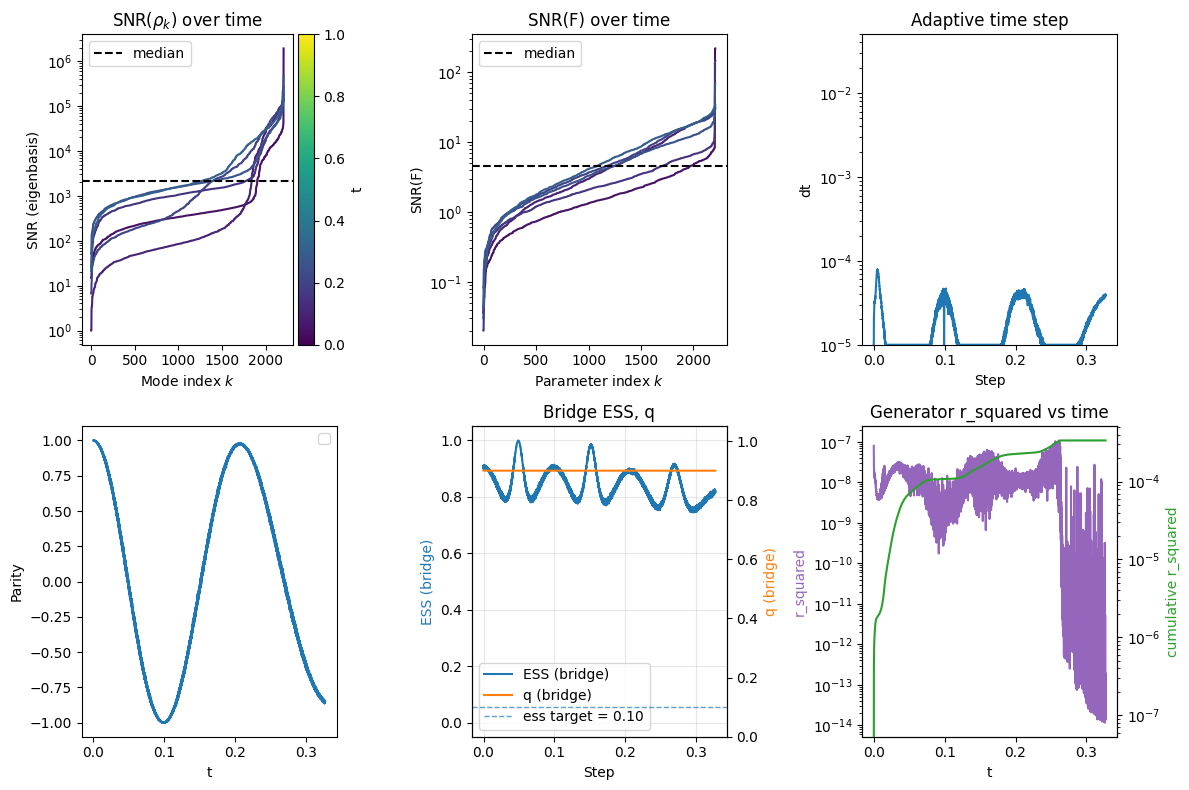

In [5]:
n_samples_tvmc = 2**13
N = 16
exp_name = f"bridge_{n_samples_tvmc}/"
save_path = f"./data/TFIM_{N}_{alpha}_parity/{exp_name}"
plot(save_path)

Load exact data from tfim_exact.ipynb
Initial parity: 1.000000
Final parity: 0.091498
Restored: True


/mnt/home/rwiersema/blurred_sampling/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/mnt/home/rwiersema/blurred_sampling/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Restored: True
Restored: True
Restored: True


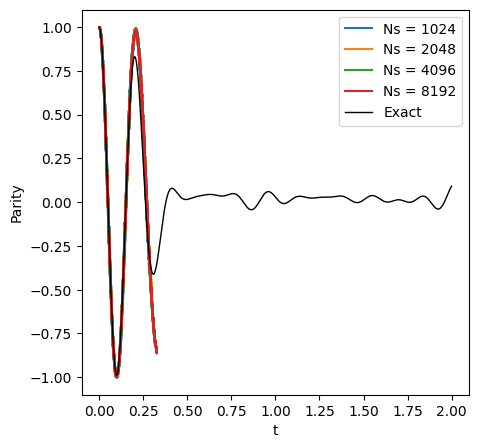

In [6]:
n_samples_list = [2**i for i in range(10, 14)]
N = 16
times_exact, parity_exact=get_exact(N, h, J, T=2.0)
fig, ax_z = plt.subplots(1, 1, figsize=(5, 5))
for n_samples in n_samples_list:
    exp_name = f"bridge_{n_samples}"
    save_path = f"./data/TFIM_{N}_{alpha}_parity/{exp_name}/"
    logger = Logger(path=save_path, fields=fields_to_track)
    print("Restored:", logger.restore())
    ax_z.plot(
        logger.data["t"]["values"],
        logger.data["parity"]["Mean"],
        label=f"Ns = {n_samples}",
        zorder=-1,
    )
    ax_z.set_xlabel("t")
    ax_z.set_ylabel(r"Parity")
ax_z.plot(
    times_exact, np.real(parity_exact), "k-", linewidth=1, label="Exact", zorder=-1
)
ax_z.legend()
plt.show()